# ELSA Depression Prediction Pipeline — Enhanced
## Predicting Wave 8 Depression from Wave 6 & 7 Predictors

**Authors:** Fiyin Akano, Zannat Chowdhury Sagar  
**Module:** MSc AI & Healthcare — University of Surrey  
**Date:** April 2026

---

### What this notebook adds over the baseline pipeline

| Addition | Purpose |
|---|---|
| **Multi-config feature registry** | Compare domain subsets systematically |
| **XGBoost** | Third model for comparison (Zhao et al. 2025 best performer on ELSA) |
| **Hyperparameter tuning** | RandomizedSearchCV for RF and XGBoost |
| **Both F1 variants** | Binary (positive-class) and macro — different questions |
| **Domain ablation** | Which feature groups drive performance? |
| **Calibration check** | Are predicted probabilities reliable for clinical use? |

---
## 0. Setup

In [1]:
# Colab: mount drive
from pathlib import Path
import sys
if Path("/content").exists():
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

Mounted at /content/drive


In [2]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score
)
from xgboost import XGBClassifier
import shap

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# Locate repo root (works from any CWD — Colab, VS Code, notebook folder)
REPO_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        f"Could not locate repo root from {Path.cwd()} — ensure config.py exists at root"
    )
sys.path.insert(0, str(REPO_ROOT))
from config import DATA_ROOT, CORE, IFS, FIN, OUTPUTS, check_paths

FIG_DIR = OUTPUTS / "figures"
RES_DIR = OUTPUTS / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
CESD_CUTOFF = 3

check_paths()
print(f"CES-D cut-off: >= {CESD_CUTOFF}")
print(f"Figures  -> {FIG_DIR}")
print(f"Results  -> {RES_DIR}")

Runtime: Colab
DATA_ROOT: /content/drive/MyDrive/ELSA/data/UKDA-5050-stata/stata/stata13_se
  ✓  W6 Core: wave_6_elsa_data_v2.dta
  ✓  W7 Core: wave_7_elsa_data.dta
  ✓  W8 Core: wave_8_elsa_data_eul_v2.dta
  ✓  W6 IFS: wave_6_ifs_derived_variables.dta
  ✓  W7 IFS: wave_7_ifs_derived_variables.dta
  ✓  W8 IFS: wave_8_ifs_derived_variables.dta
  ✓  W6 Financial: wave_6_financial_derived_variables.dta
  ✓  W7 Financial: wave_7_financial_derived_variables.dta
  ✓  W8 Financial: wave_8_financial_derived_variables.dta

All data files found.
CES-D cut-off: >= 3
Figures  -> /content/outputs/figures
Results  -> /content/outputs/results


---
## 1. Data Loading & Merging

In [3]:
IFS_COLS = [
    "idauniq", "age", "sex", "nonwhite", "marstat", "couple",
    "srh_hrs", "llsill", "hlimwrk",
    "hemobwa", "hemobsi", "hemobch", "hemobcs", "hemobcl",
    "hemobst", "hemobre", "hemobpu", "hemobli", "hemobpi", "hemob96",
    "headldr", "headlwa", "headlba", "headlea", "headlbe", "headlwc",
    "headlma", "headlda", "headlpr", "headlsh", "headlph",
    "headlco", "headlme", "headlho", "headlmo", "headl96",
    "memtotb", "execnn",
    "ecpos", "qual3",
    "findiff", "ndepriv", "lackresb",
    "famtype", "tenure", "nsibs", "ngrandch",
    "smokerstat",
    "cesd_sc", "cesd_na",
]
CORE_COLS = [
    "idauniq",
    "Hehelf", "Heill",
    "HeActa", "HeActb", "HeActc",
    "hediabp", "hediadi", "hediami", "hediast", "hediahf",
    "hediaar", "hediaan",
    "scint",
    "chinhh", "chouthh",
]
FIN_COLS = ["idauniq", "totwq5_bu_s"]
SURVEY_MISSING = {-1, -2, -8, -9}


def load_wave(wave: int, suffix: str) -> pd.DataFrame:
    ifs  = pd.read_stata(str(IFS[wave]),  convert_categoricals=False, columns=IFS_COLS)
    core = pd.read_stata(str(CORE[wave]), convert_categoricals=False, columns=CORE_COLS)
    fin  = pd.read_stata(str(FIN[wave]),  convert_categoricals=False, columns=FIN_COLS)
    df = ifs.merge(core, on="idauniq", how="inner", suffixes=("", "_core"))
    df = df.merge(fin, on="idauniq", how="left")
    # Lowercase all column names for consistency
    df.columns = [c.lower() for c in df.columns]
    rename = {c: f"{c}_{suffix}" for c in df.columns if c != "idauniq"}
    return df.rename(columns=rename)


print("Loading waves...")
w6 = load_wave(6, "w6")
w7 = load_wave(7, "w7")
print(f"  Wave 6: {len(w6)} rows, {w6.shape[1]-1} features")
print(f"  Wave 7: {len(w7)} rows, {w7.shape[1]-1} features")

# W8: outcome only
w8_ifs = pd.read_stata(str(IFS[8]), convert_categoricals=False,
                        columns=["idauniq", "cesd_sc", "cesd_na"])
w8_ifs.columns = [c.lower() for c in w8_ifs.columns]
w8_ifs = w8_ifs.rename(columns={"cesd_sc": "cesd_sc_w8", "cesd_na": "cesd_na_w8"})
print(f"  Wave 8 outcome: {len(w8_ifs)} rows")

panel = w6.merge(w7, on="idauniq", how="inner").merge(w8_ifs, on="idauniq", how="inner")
print(f"\nPanel (all three waves): {len(panel)} participants")

Loading waves...
  Wave 6: 10601 rows, 65 features
  Wave 7: 9666 rows, 65 features
  Wave 8 outcome: 8445 rows

Panel (all three waves): 7535 participants


---
## 1b. Outcome Variable Construction

Using **validated IFS-derived `cesd_sc`** (0–8 scale). Threshold ≥3 = depressed (Steffick, 2000).  
This avoids the scoring artefact from earlier notebook `psced_items_as_0_to_3` (produced range 8–16, ~74% prevalence).

Analytic sample: 7211 participants
  Depressed (CES-D >= 3): 1372 (19.0%)
  Not depressed:                     5839 (81.0%)
  Class ratio:                       1:4.3


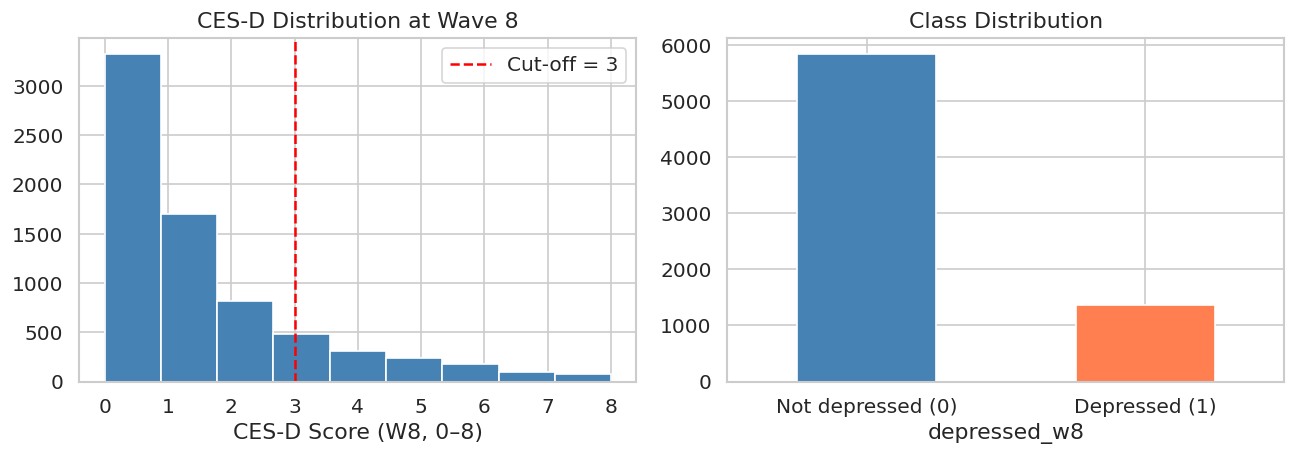

In [4]:
panel = panel[~panel["cesd_sc_w8"].isin(SURVEY_MISSING)].copy()
panel = panel.dropna(subset=["cesd_sc_w8"])
panel["depressed_w8"] = (panel["cesd_sc_w8"] >= CESD_CUTOFF).astype(int)

n_dep = panel["depressed_w8"].sum()
n_not = len(panel) - n_dep
prev  = n_dep / len(panel)
print(f"Analytic sample: {len(panel)} participants")
print(f"  Depressed (CES-D >= {CESD_CUTOFF}): {n_dep} ({prev:.1%})")
print(f"  Not depressed:                     {n_not} ({1-prev:.1%})")
print(f"  Class ratio:                       1:{n_not/n_dep:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
panel["cesd_sc_w8"].hist(bins=9, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].axvline(CESD_CUTOFF, color="red", ls="--", label=f"Cut-off = {CESD_CUTOFF}")
axes[0].set_xlabel("CES-D Score (W8, 0–8)")
axes[0].set_title("CES-D Distribution at Wave 8")
axes[0].legend()
panel["depressed_w8"].value_counts().sort_index().plot.bar(
    ax=axes[1], color=["steelblue", "coral"], edgecolor="white")
axes[1].set_xticklabels(["Not depressed (0)", "Depressed (1)"], rotation=0)
axes[1].set_title("Class Distribution")
plt.tight_layout()
plt.savefig(FIG_DIR / "outcome_distribution.png", bbox_inches="tight")
plt.show()

---
## 2. Preprocessing

### Steps:
1. **Recode survey missing codes** (-1, -2, -8, -9) → NaN across all predictors
2. **Drop near-empty columns** (>40% missing after recoding)
3. **Coerce all predictors to numeric** (ELSA variables are integer-coded; sklearn handles the rest)
4. Imputation and scaling happen inside sklearn Pipelines (Section 4) to prevent data leakage

In [5]:
exclude = {"idauniq", "cesd_sc_w8", "cesd_na_w8", "depressed_w8"}
predictor_cols = [c for c in panel.columns if c not in exclude]
print(f"Total predictor candidates: {len(predictor_cols)}")

for col in predictor_cols:
    panel[col] = pd.to_numeric(panel[col], errors="coerce")
    panel.loc[panel[col].isin(SURVEY_MISSING), col] = np.nan

# Drop columns >40% missing — computed on training split only to avoid leakage
from sklearn.model_selection import train_test_split as _tts
_Xm, _, _, _ = _tts(panel[predictor_cols], panel["depressed_w8"],
                     test_size=0.25, stratify=panel["depressed_w8"], random_state=SEED)
miss_pct  = _Xm.isna().mean().sort_values(ascending=False)
high_miss = miss_pct[miss_pct > 0.40].index.tolist()
print(f"Dropping {len(high_miss)} columns with >40% missing: {high_miss}")
predictor_cols = [c for c in predictor_cols if c not in high_miss]

# Wave-symmetry enforcement — if a stem fails missingness at either wave,
# drop both waves. Prevents the longitudinal model from using a predictor
# that is only partially available across time.
def _stem(col):
    for sfx in ("_w6", "_w7", "_w8"):
        if col.endswith(sfx):
            return col[:-3]
    return col

dropped_stems = {_stem(c) for c in high_miss}
asymmetric = [c for c in predictor_cols
              if _stem(c) in dropped_stems and c not in high_miss]
if asymmetric:
    print(f"Wave-symmetry: also dropping W6 counterparts: {asymmetric}")
    predictor_cols = [c for c in predictor_cols if c not in asymmetric]

print(f"Remaining predictors after symmetry enforcement: {len(predictor_cols)}")

Total predictor candidates: 130
Dropping 1 columns with >40% missing: ['ndepriv_w7']
Wave-symmetry: also dropping W6 counterparts: ['ndepriv_w6']
Remaining predictors after symmetry enforcement: 128


---
## 3. Feature Engineering

In [6]:
MOBILITY_ITEMS = ["hemobwa","hemobsi","hemobch","hemobcs","hemobcl",
                   "hemobst","hemobre","hemobpu","hemobli","hemobpi"]
ADL_ITEMS  = ["headldr","headlwa","headlba","headlea","headlbe","headlwc"]
IADL_ITEMS = ["headlma","headlda","headlpr","headlsh","headlph",
               "headlco","headlme","headlho","headlmo"]

def safe_sum(df, items, suffix):
    cols = [f"{item}_{suffix}" for item in items]
    present = [c for c in cols if c in df.columns]
    if not present:
        return pd.Series(np.nan, index=df.index)
    return df[present].sum(axis=1, min_count=1)

for sfx in ["w6", "w7"]:
    panel[f"mobility_count_{sfx}"]   = safe_sum(panel, MOBILITY_ITEMS, sfx)
    panel[f"adl_count_{sfx}"]        = safe_sum(panel, ADL_ITEMS, sfx)
    panel[f"iadl_count_{sfx}"]       = safe_sum(panel, IADL_ITEMS, sfx)
    panel[f"functional_burden_{sfx}"] = panel[f"adl_count_{sfx}"] + panel[f"iadl_count_{sfx}"]

panel["cesd_change"]     = panel["cesd_sc_w7"] - panel["cesd_sc_w6"]
panel["mobility_change"] = panel["mobility_count_w7"] - panel["mobility_count_w6"]

engineered = [
    "mobility_count_w6", "mobility_count_w7",
    "adl_count_w6", "adl_count_w7",
    "iadl_count_w6", "iadl_count_w7",
    "functional_burden_w6", "functional_burden_w7",
    "cesd_change", "mobility_change",
]
predictor_cols = list(dict.fromkeys(predictor_cols + engineered))
print(f"Total predictors after engineering: {len(predictor_cols)}")

Total predictors after engineering: 138


---
## 4. Feature Set Registry (Multi-Config)

We define named feature configurations for systematic comparison.  
Each config is run through the identical pipeline — results are directly comparable.

| Config | Description |
|---|---|
| `full_139` | All 139 features (W6 + W7) — Fiyin's baseline |
| `no_cesd` | Remove prior CES-D — tests independent predictive value |
| `health_only` | Self-rated health + chronic conditions only |
| `function_cog` | Mobility, ADL/IADL, cognition only |
| `socioeconomic` | Economic + social features only |
| `w6_only` | Wave 6 features only — single-wave baseline (mirrors Zannat's prior work) |

In [7]:
DOMAINS = {
    "prior_depression":  [c for c in predictor_cols if "cesd" in c.lower()],
    "demographics":      [c for c in predictor_cols if any(c.startswith(p) for p in
                           ["age_","sex_","nonwhite_","marstat_","couple_"])],
    "self_rated_health": [c for c in predictor_cols if any(p in c.lower() for p in
                           ["hehelf","heill","srh_hrs","llsill","hlimwrk"])],
    "chronic_conditions":[c for c in predictor_cols if c.lower().startswith("hedia")],
    "mobility_function": [c for c in predictor_cols if any(p in c.lower() for p in
                           ["mobility","adl_count","iadl_count","functional_burden",
                            "hemob96","headl96"])],
    "cognition":         [c for c in predictor_cols if any(p in c for p in
                           ["memtotb","execnn"])],
    "socioeconomic":     [c for c in predictor_cols if any(p in c.lower() for p in
                           ["ecpos","qual3","findiff","lackres","totwq5"])],
    "social_housing":    [c for c in predictor_cols if any(p in c.lower() for p in
                           ["famtype","tenure","nsibs","ngrandch","chinhh",
                            "chouthh","smokerstat"])],
    "lifestyle_digital": [c for c in predictor_cols if any(p in c.lower() for p in
                           ["heact","scint","scptr"])],
}

for d, cols in DOMAINS.items():
    print(f"  {d:22s}: {len(cols):3d} features")

FEATURE_CONFIGS = {
    "full_139":    predictor_cols,

    "no_cesd":     [c for c in predictor_cols
                    if c not in DOMAINS["prior_depression"]],

    "health_only": DOMAINS["self_rated_health"] + DOMAINS["chronic_conditions"],

    "function_cog": DOMAINS["mobility_function"] + DOMAINS["cognition"],

    "socioeconomic": DOMAINS["socioeconomic"] + DOMAINS["social_housing"],

    # Pure W6-only — excludes cesd_change (uses W7 data) for a clean single-wave baseline
    "w6_only":     [c for c in predictor_cols if c.endswith("_w6")],
}

print("\nFeature configs:")
for name, cols in FEATURE_CONFIGS.items():
    print(f"  {name:20s}: {len(cols)} features")

  prior_depression      :   5 features
  demographics          :  10 features
  self_rated_health     :  10 features
  chronic_conditions    :  14 features
  mobility_function     :  13 features
  cognition             :   4 features
  socioeconomic         :  10 features
  social_housing        :  14 features
  lifestyle_digital     :   8 features

Feature configs:
  full_139            : 138 features
  no_cesd             : 133 features
  health_only         : 24 features
  function_cog        : 17 features
  socioeconomic       : 24 features
  w6_only             : 68 features


---
## 5. Train/Test Split

In [8]:
X_full = panel[predictor_cols].copy()
y      = panel["depressed_w8"].copy()

# Single split — reused across all configs to keep test sets comparable
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.25, random_state=SEED, stratify=y
)
print(f"Training: {len(X_train_full)} ({y_train.mean():.1%} depressed)")
print(f"Test:     {len(X_test_full)} ({y_test.mean():.1%} depressed)")
print("NOTE: same train/test split used for all configs — results are directly comparable.")

Training: 5408 (19.0% depressed)
Test:     1803 (19.0% depressed)
NOTE: same train/test split used for all configs — results are directly comparable.


---
## 6. Model Definitions (LR + RF + XGBoost)

In [9]:
pos_weight = int((y_train == 0).sum() / (y_train == 1).sum())
print(f"XGBoost scale_pos_weight = {pos_weight} (handles class imbalance)")

def make_models():
    """Return fresh (unfitted) model dict. Call per config to avoid state sharing."""
    return {
        "Logistic Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=5000, class_weight="balanced",
                random_state=SEED, solver="lbfgs", C=1.0
            )),
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=300, class_weight="balanced",
                random_state=SEED, n_jobs=-1,
                max_depth=15, min_samples_leaf=10
            )),
        ]),
        "XGBoost": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(
                n_estimators=300, max_depth=5, learning_rate=0.05,
                scale_pos_weight=pos_weight,
                random_state=SEED, eval_metric="logloss",
                verbosity=0, n_jobs=-1
            )),
        ]),
    }

print("Model factory defined: LR, RF, XGBoost")

XGBoost scale_pos_weight = 4 (handles class imbalance)
Model factory defined: LR, RF, XGBoost


---
## 7. Full Pipeline Run — All Configs × All Models

Each config × model combination is trained and evaluated on the same held-out test set.  
We report both **binary F1** (positive class / depression detection) and **macro F1** (overall balance).  
With ~19% prevalence, these tell different stories — both are shown.

In [10]:
import copy

all_results = []
fitted_store = {}  # (config, model_name) -> fitted pipeline

for config_name, feat_cols in FEATURE_CONFIGS.items():
    feat_cols = [c for c in feat_cols if c in X_train_full.columns]
    X_tr = X_train_full[feat_cols]
    X_te = X_test_full[feat_cols]

    for model_name, pipe in make_models().items():
        pipe.fit(X_tr, y_train)
        fitted_store[(config_name, model_name)] = pipe

        y_pred  = pipe.predict(X_te)
        y_proba = pipe.predict_proba(X_te)[:, 1]

        all_results.append({
            "config":      config_name,
            "model":       model_name,
            "n_features":  len(feat_cols),
            "AUC-ROC":     round(roc_auc_score(y_test, y_proba), 4),
            "F1_binary":   round(f1_score(y_test, y_pred, average="binary"), 4),
            "F1_macro":    round(f1_score(y_test, y_pred, average="macro"), 4),
            "Precision":   round(precision_score(y_test, y_pred), 4),
            "Recall":      round(recall_score(y_test, y_pred), 4),
            "Accuracy":    round(accuracy_score(y_test, y_pred), 4),
            "Avg_Prec":    round(average_precision_score(y_test, y_proba), 4),
        })
        print(f"  {config_name:20s} | {model_name:20s} | "
              f"AUC={all_results[-1]['AUC-ROC']:.4f}  "
              f"F1b={all_results[-1]['F1_binary']:.4f}  "
              f"F1m={all_results[-1]['F1_macro']:.4f}")

results_df = pd.DataFrame(all_results)
results_df.to_csv(RES_DIR / "all_config_results.csv", index=False)
print("\nSaved: all_config_results.csv")

  full_139             | Logistic Regression  | AUC=0.8349  F1b=0.5591  F1m=0.7110
  full_139             | Random Forest        | AUC=0.8398  F1b=0.5786  F1m=0.7290
  full_139             | XGBoost              | AUC=0.8288  F1b=0.5789  F1m=0.7361
  no_cesd              | Logistic Regression  | AUC=0.7677  F1b=0.4696  F1m=0.6371
  no_cesd              | Random Forest        | AUC=0.7739  F1b=0.5019  F1m=0.6798
  no_cesd              | XGBoost              | AUC=0.7429  F1b=0.4613  F1m=0.6568
  health_only          | Logistic Regression  | AUC=0.7454  F1b=0.4582  F1m=0.6278
  health_only          | Random Forest        | AUC=0.7453  F1b=0.4636  F1m=0.6324
  health_only          | XGBoost              | AUC=0.7150  F1b=0.4372  F1m=0.6229
  function_cog         | Logistic Regression  | AUC=0.7288  F1b=0.4541  F1m=0.6328
  function_cog         | Random Forest        | AUC=0.7235  F1b=0.4466  F1m=0.6301
  function_cog         | XGBoost              | AUC=0.7072  F1b=0.4230  F1m=0.6224
  so

In [11]:
# ── Summary table: full_139 config (main results) ────────────────────────────
print("=== Main results (full_139 config) ===")
main = results_df[results_df["config"] == "full_139"][
    ["model", "AUC-ROC", "F1_binary", "F1_macro",
     "Precision", "Recall", "Accuracy", "Avg_Prec"]
]
print(main.to_string(index=False))

print("\n--- NOTE on F1 variants ---")
print("F1_binary = F1 for the 'depressed' class only (positive class precision × recall).")
print("  Use this when the question is: how well do we detect depression?")
print("F1_macro  = unweighted mean of F1 for both classes.")
print("  Use this when the question is: how balanced is the model overall?")
print("  With 19% prevalence, macro F1 is higher because the model is")
print("  much better at identifying non-depressed participants.")

=== Main results (full_139 config) ===
              model  AUC-ROC  F1_binary  F1_macro  Precision  Recall  Accuracy  Avg_Prec
Logistic Regression   0.8349     0.5591    0.7110     0.4668  0.6968    0.7909    0.6173
      Random Forest   0.8398     0.5786    0.7290     0.5054  0.6764    0.8125    0.6135
            XGBoost   0.8288     0.5789    0.7361     0.5466  0.6152    0.8297    0.6188

--- NOTE on F1 variants ---
F1_binary = F1 for the 'depressed' class only (positive class precision × recall).
  Use this when the question is: how well do we detect depression?
F1_macro  = unweighted mean of F1 for both classes.
  Use this when the question is: how balanced is the model overall?
  With 19% prevalence, macro F1 is higher because the model is
  much better at identifying non-depressed participants.


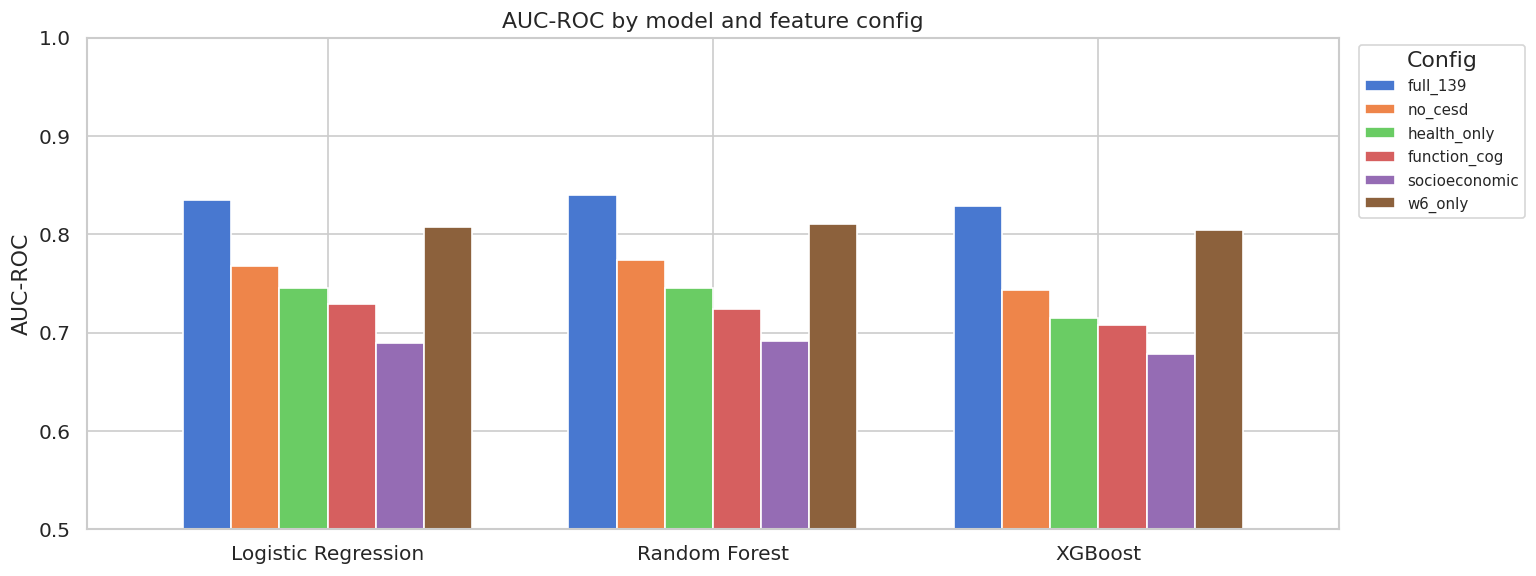

Saved: auc_all_configs.png


In [12]:
# ── AUC comparison across all configs ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
pivot = results_df.pivot_table(
    index="model", columns="config", values="AUC-ROC"
)[list(FEATURE_CONFIGS.keys())]
pivot.plot.bar(ax=ax, edgecolor="white", width=0.75)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("AUC-ROC")
ax.set_title("AUC-ROC by model and feature config")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Config", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "auc_all_configs.png", bbox_inches="tight")
plt.show()
print("Saved: auc_all_configs.png")

---
## 8. Hyperparameter Tuning (RF and XGBoost, full_139 config)

We use `RandomizedSearchCV` on the training set with 5-fold stratified CV.  
Tuning is done once on the full feature set — the best parameters are then re-used for the full_139 model.

In [13]:
from scipy.stats import randint, uniform

X_tr_full = X_train_full[FEATURE_CONFIGS["full_139"]]

cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Random Forest tuning ─────────────────────────────────────────────────────
rf_param_dist = {
    "clf__n_estimators":   randint(200, 600),
    "clf__max_depth":      [6, 8, 10, 12, 15, None],
    "clf__min_samples_leaf": randint(5, 25),
    "clf__max_features":   ["sqrt", "log2", 0.3, 0.5],
}
rf_base = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        class_weight="balanced", random_state=SEED, n_jobs=-1
    )),
])
rf_search = RandomizedSearchCV(
    rf_base, rf_param_dist, n_iter=30,
    scoring="roc_auc", cv=cv_tune, random_state=SEED,
    n_jobs=-1, verbose=1, refit=True
)
print("Tuning Random Forest (30 iterations × 5-fold CV)...")
rf_search.fit(X_tr_full, y_train)
print(f"Best RF AUC (CV): {rf_search.best_score_:.4f}")
print(f"Best RF params:   {rf_search.best_params_}")

Tuning Random Forest (30 iterations × 5-fold CV)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF AUC (CV): 0.8449
Best RF params:   {'clf__max_depth': 10, 'clf__max_features': 0.3, 'clf__min_samples_leaf': 21, 'clf__n_estimators': 591}


In [14]:
# ── XGBoost tuning ───────────────────────────────────────────────────────────
xgb_param_dist = {
    "clf__n_estimators":  randint(200, 600),
    "clf__max_depth":     randint(3, 8),
    "clf__learning_rate": uniform(0.02, 0.15),
    "clf__subsample":     uniform(0.6, 0.4),
    "clf__colsample_bytree": uniform(0.5, 0.5),
    "clf__reg_alpha":     uniform(0, 2),
    "clf__reg_lambda":    uniform(0.5, 2),
}
xgb_base = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(
        scale_pos_weight=pos_weight,
        random_state=SEED, eval_metric="logloss",
        verbosity=0, n_jobs=-1
    )),
])
xgb_search = RandomizedSearchCV(
    xgb_base, xgb_param_dist, n_iter=30,
    scoring="roc_auc", cv=cv_tune, random_state=SEED,
    n_jobs=-1, verbose=1, refit=True
)
print("Tuning XGBoost (30 iterations × 5-fold CV)...")
xgb_search.fit(X_tr_full, y_train)
print(f"Best XGB AUC (CV): {xgb_search.best_score_:.4f}")
print(f"Best XGB params:   {xgb_search.best_params_}")

Tuning XGBoost (30 iterations × 5-fold CV)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB AUC (CV): 0.8370
Best XGB params:   {'clf__colsample_bytree': np.float64(0.9303652916281717), 'clf__learning_rate': np.float64(0.021042819579678605), 'clf__max_depth': 5, 'clf__n_estimators': 336, 'clf__reg_alpha': np.float64(0.9696599427179664), 'clf__reg_lambda': np.float64(1.8848720657805407), 'clf__subsample': np.float64(0.7077649335194086)}


In [15]:
# ── Evaluate tuned models on test set ────────────────────────────────────────
X_te_full = X_test_full[FEATURE_CONFIGS["full_139"]]

tuned_results = []
tuned_models  = {
    "RF (tuned)":  rf_search.best_estimator_,
    "XGB (tuned)": xgb_search.best_estimator_,
}

# Also include baseline LR for reference
lr_base = fitted_store[("full_139", "Logistic Regression")]
tuned_models["LR (baseline)"] = lr_base

for name, pipe in tuned_models.items():
    y_pred  = pipe.predict(X_te_full)
    y_proba = pipe.predict_proba(X_te_full)[:, 1]
    tuned_results.append({
        "Model":     name,
        "AUC-ROC":   round(roc_auc_score(y_test, y_proba), 4),
        "F1_binary": round(f1_score(y_test, y_pred, average="binary"), 4),
        "F1_macro":  round(f1_score(y_test, y_pred, average="macro"), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
    })

tuned_df = pd.DataFrame(tuned_results)
print("=== Tuned model results (test set) ===")
print(tuned_df.to_string(index=False))
tuned_df.to_csv(RES_DIR / "tuned_model_results.csv", index=False)

=== Tuned model results (test set) ===
        Model  AUC-ROC  F1_binary  F1_macro  Precision  Recall
   RF (tuned)   0.8481     0.5816    0.7274     0.4919  0.7114
  XGB (tuned)   0.8434     0.5797    0.7309     0.5123  0.6676
LR (baseline)   0.8349     0.5591    0.7110     0.4668  0.6968


---
## 9. Evaluation — Full Results (Best Model per Config)

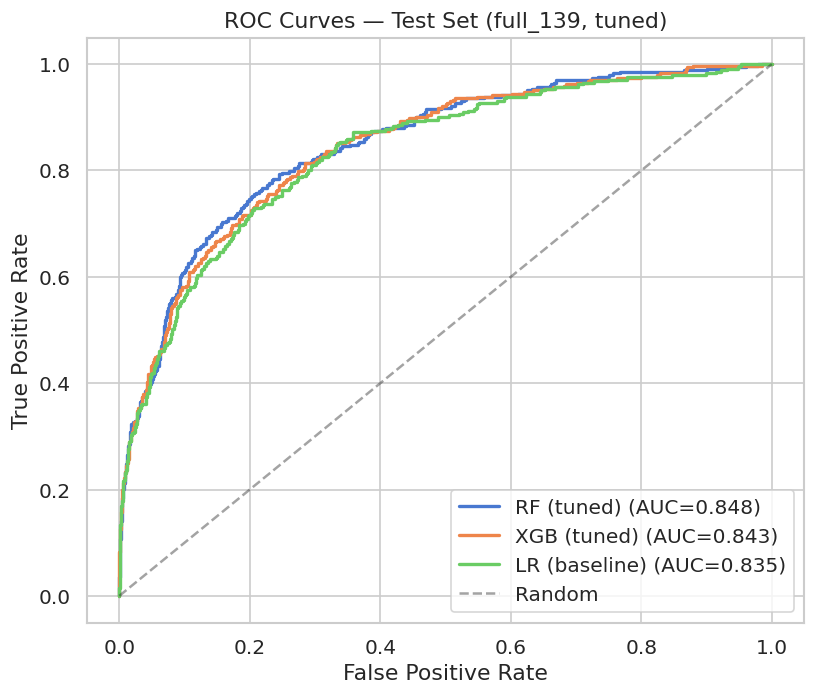

In [16]:
# ROC curves — full_139 config, all three models (including tuned)
fig, ax = plt.subplots(figsize=(7, 6))

for name, pipe in tuned_models.items():
    y_proba = pipe.predict_proba(X_te_full)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})", linewidth=2)

ax.plot([0,1],[0,1],"k--",alpha=0.4,label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Test Set (full_139, tuned)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curves_tuned.png", bbox_inches="tight")
plt.show()

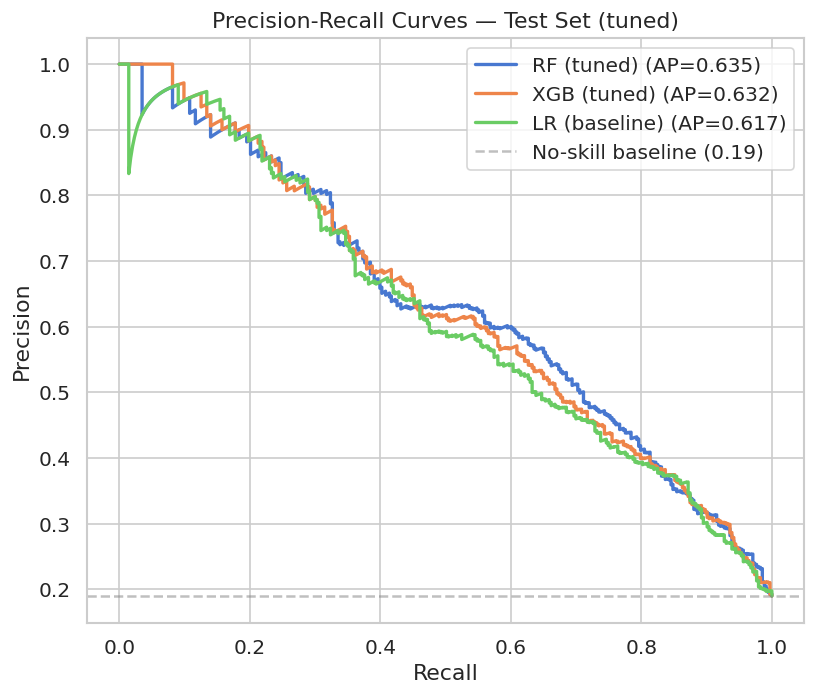

In [17]:
# Precision-Recall curves — more informative at 19% prevalence
fig, ax = plt.subplots(figsize=(7, 6))
for name, pipe in tuned_models.items():
    y_proba = pipe.predict_proba(X_te_full)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})", linewidth=2)
ax.axhline(y_test.mean(), color="grey", ls="--", alpha=0.5,
           label=f"No-skill baseline ({y_test.mean():.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — Test Set (tuned)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "pr_curves_tuned.png", bbox_inches="tight")
plt.show()

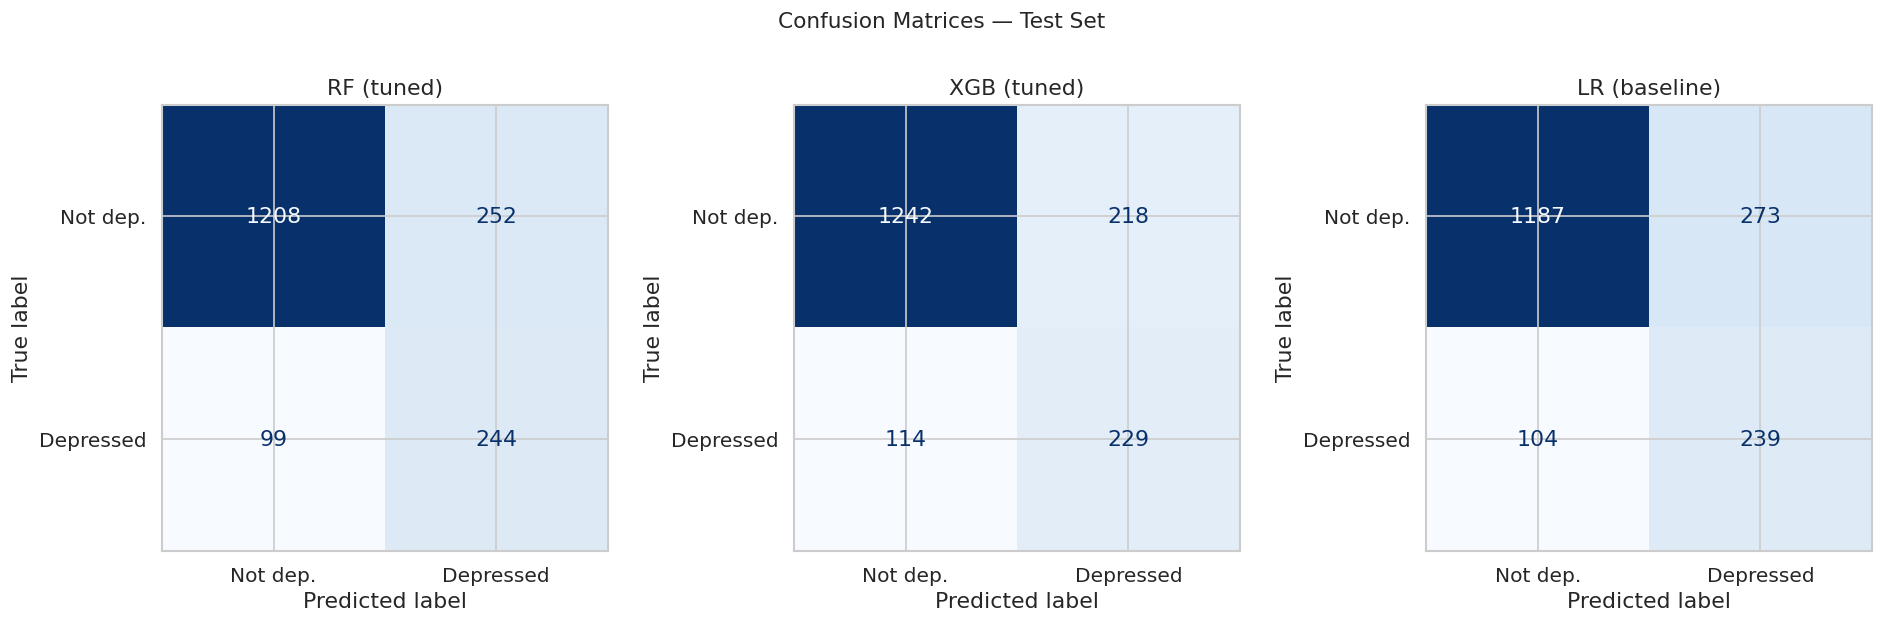

In [18]:
# Confusion matrices — all three tuned models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, pipe) in zip(axes, tuned_models.items()):
    y_pred = pipe.predict(X_te_full)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Not dep.", "Depressed"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.suptitle("Confusion Matrices — Test Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrices_tuned.png", bbox_inches="tight")
plt.show()

---
## 10. Leakage Sensitivity — Complete Domain Ablation

We test AUC when each domain is **removed one at a time** from the full feature set.  
The domain with the largest AUC drop is the most informative.

This extends Fiyin's with/without CES-D analysis to all domains.

In [19]:
ablation_results = []

# Baseline: full_139 with best model (tuned RF)
best_pipe_name = tuned_df.loc[tuned_df["AUC-ROC"].idxmax(), "Model"]
best_pipe = tuned_models[best_pipe_name]
baseline_auc = roc_auc_score(
    y_test, best_pipe.predict_proba(X_te_full)[:, 1]
)
ablation_results.append({"removed": "None (full)",
                          "n_features": len(FEATURE_CONFIGS["full_139"]),
                          "AUC": round(baseline_auc, 4),
                          "AUC_drop": 0.0})

for domain_name, domain_cols in DOMAINS.items():
    remaining = [c for c in FEATURE_CONFIGS["full_139"] if c not in domain_cols]
    if not remaining:
        continue
    X_tr_abl = X_train_full[remaining]
    X_te_abl = X_test_full[remaining]

    # Fresh RF with default tuned params but retrained without domain
    pipe_abl = copy.deepcopy(rf_search.best_estimator_)
    pipe_abl.fit(X_tr_abl, y_train)
    auc_abl = roc_auc_score(y_test, pipe_abl.predict_proba(X_te_abl)[:, 1])
    drop = round(baseline_auc - auc_abl, 4)

    ablation_results.append({
        "removed": domain_name,
        "n_features": len(remaining),
        "AUC": round(auc_abl, 4),
        "AUC_drop": drop,
    })
    print(f"  Remove {domain_name:22s}: AUC={auc_abl:.4f}  drop={drop:+.4f}")

ablation_df = pd.DataFrame(ablation_results).sort_values("AUC_drop", ascending=False)
ablation_df.to_csv(RES_DIR / "domain_ablation.csv", index=False)
print("\nSaved: domain_ablation.csv")
print(ablation_df.to_string(index=False))

  Remove prior_depression      : AUC=0.7717  drop=+0.0764
  Remove demographics          : AUC=0.8480  drop=+0.0001
  Remove self_rated_health     : AUC=0.8432  drop=+0.0049
  Remove chronic_conditions    : AUC=0.8485  drop=-0.0004
  Remove mobility_function     : AUC=0.8492  drop=-0.0011
  Remove cognition             : AUC=0.8494  drop=-0.0013
  Remove socioeconomic         : AUC=0.8488  drop=-0.0007
  Remove social_housing        : AUC=0.8491  drop=-0.0010
  Remove lifestyle_digital     : AUC=0.8489  drop=-0.0008

Saved: domain_ablation.csv
           removed  n_features    AUC  AUC_drop
  prior_depression         133 0.7717    0.0764
 self_rated_health         128 0.8432    0.0049
      demographics         128 0.8480    0.0001
       None (full)         138 0.8481    0.0000
chronic_conditions         124 0.8485   -0.0004
     socioeconomic         128 0.8488   -0.0007
 lifestyle_digital         130 0.8489   -0.0008
    social_housing         124 0.8491   -0.0010
 mobility_function

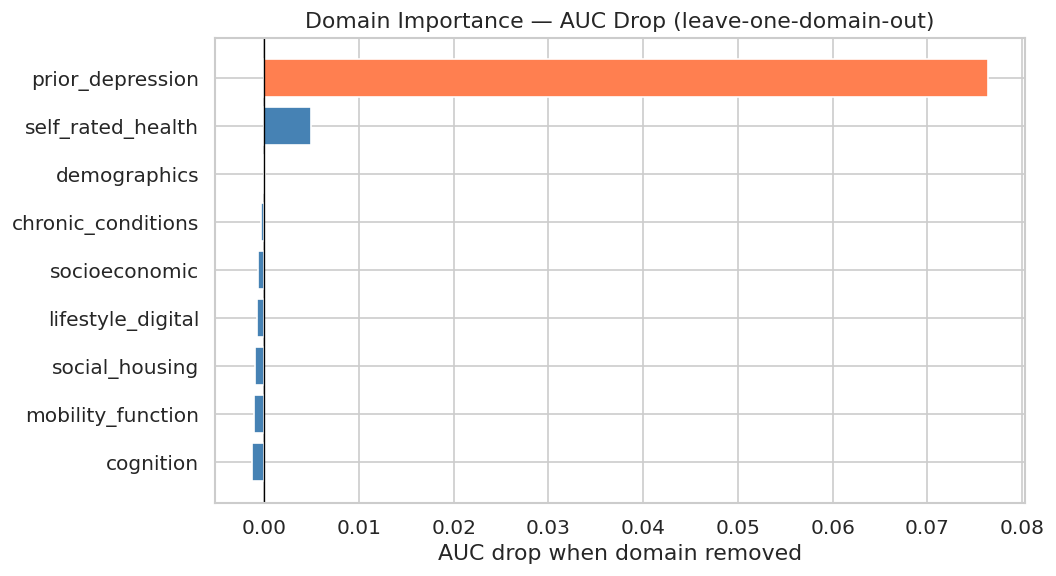

Saved: domain_ablation.png


In [20]:
# Domain ablation bar chart
plot_data = ablation_df[ablation_df["removed"] != "None (full)"].copy()
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["coral" if d > 0.02 else "steelblue" for d in plot_data["AUC_drop"]]
ax.barh(plot_data["removed"], plot_data["AUC_drop"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("AUC drop when domain removed")
ax.set_title("Domain Importance — AUC Drop (leave-one-domain-out)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "domain_ablation.png", bbox_inches="tight")
plt.show()
print("Saved: domain_ablation.png")

---
## 11. Calibration Check

A well-calibrated model means: when it predicts 30% probability of depression,  
roughly 30% of those people are actually depressed.  
Poor calibration = predicted probabilities are unreliable for clinical decision support.

We check calibration for all three models and optionally apply isotonic regression calibration.

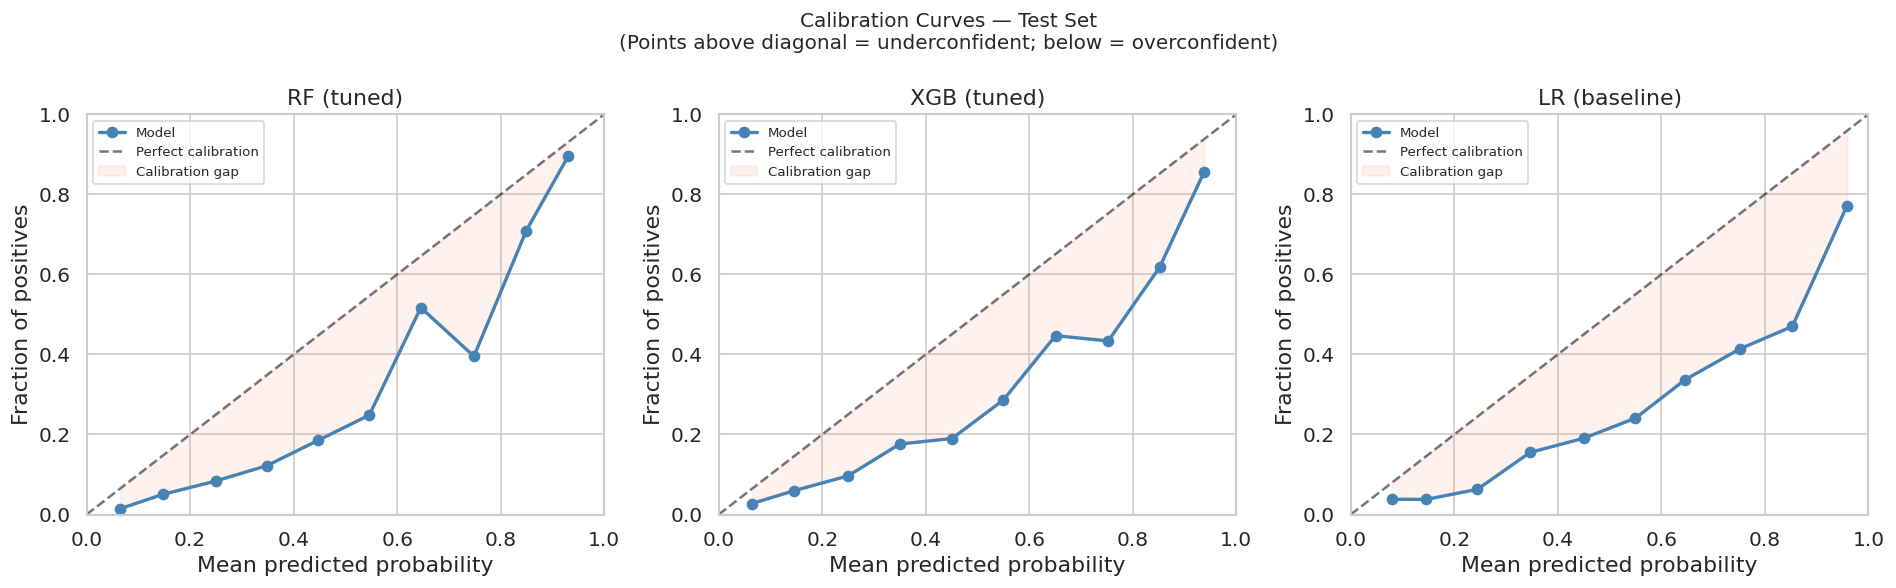

Saved: calibration_curves.png


In [21]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, pipe) in zip(axes, tuned_models.items()):
    y_proba = pipe.predict_proba(X_te_full)[:, 1]

    # Calibration curve
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

    ax.plot(prob_pred, prob_true, marker="o", linewidth=2,
            label="Model", color="steelblue")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.6, label="Perfect calibration")
    ax.fill_between(prob_pred, prob_true, prob_pred,
                    alpha=0.1, color="coral", label="Calibration gap")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(f"{name}")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle("Calibration Curves — Test Set\n"
             "(Points above diagonal = underconfident; below = overconfident)",
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "calibration_curves.png", bbox_inches="tight")
plt.show()
print("Saved: calibration_curves.png")

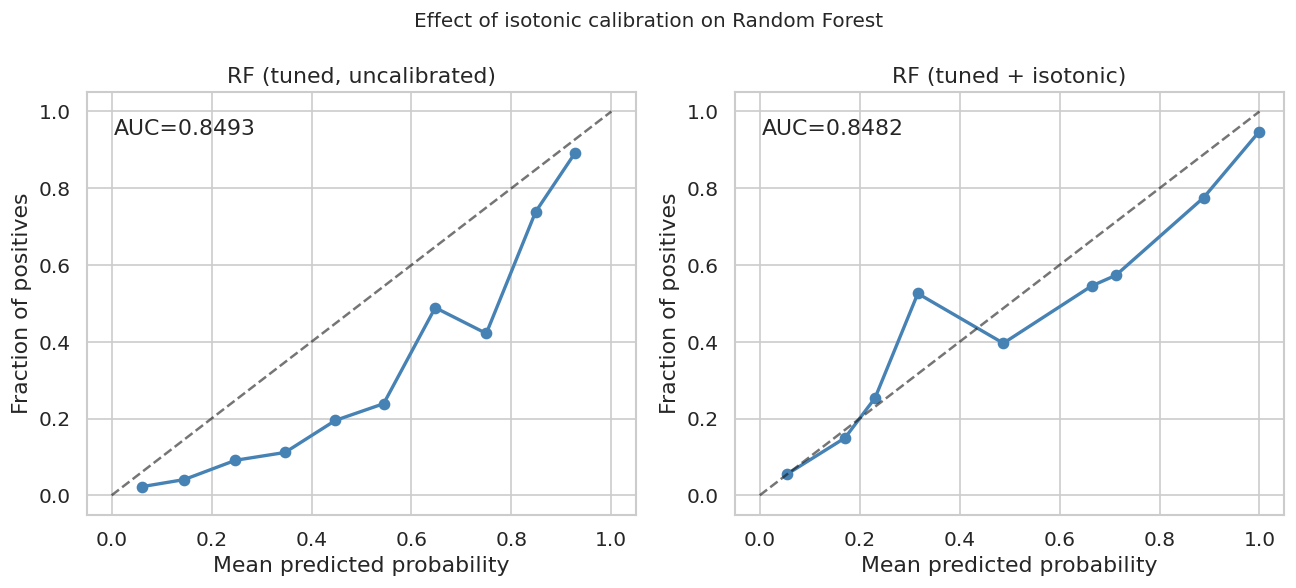

Uncalibrated RF AUC: 0.8493
Calibrated RF AUC:   0.8482
NOTE: Calibration preserves AUC but makes probabilities more reliable.


In [22]:
# ── Apply isotonic calibration to the best model ─────────────────────────────
# CalibratedClassifierCV wraps the fitted model — no data leakage as
# we use the cv='prefit' mode which calibrates on a held-out slice

# Split train into train_cal + cal_set for calibration fitting
X_tr_cal, X_cal, y_tr_cal, y_cal = train_test_split(
    X_tr_full, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

# Re-fit best model on train_cal only
pipe_for_cal = copy.deepcopy(rf_search.best_estimator_)
pipe_for_cal.fit(X_tr_cal, y_tr_cal)

# Calibrate
calibrated = CalibratedClassifierCV(pipe_for_cal, method="isotonic", cv="prefit")
calibrated.fit(X_cal, y_cal)

# Compare uncalibrated vs calibrated on test
y_proba_raw = pipe_for_cal.predict_proba(X_te_full)[:, 1]
y_proba_cal = calibrated.predict_proba(X_te_full)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (label, y_p) in zip(axes, [
    ("RF (tuned, uncalibrated)", y_proba_raw),
    ("RF (tuned + isotonic)",    y_proba_cal),
]):
    prob_true, prob_pred = calibration_curve(y_test, y_p, n_bins=10)
    ax.plot(prob_pred, prob_true, marker="o", linewidth=2, color="steelblue")
    ax.plot([0,1],[0,1],"k--",alpha=0.6)
    ax.set_title(label)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    auc_v = roc_auc_score(y_test, y_p)
    ax.text(0.05, 0.9, f"AUC={auc_v:.4f}", transform=ax.transAxes)

plt.suptitle("Effect of isotonic calibration on Random Forest", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "calibration_isotonic.png", bbox_inches="tight")
plt.show()

print(f"Uncalibrated RF AUC: {roc_auc_score(y_test, y_proba_raw):.4f}")
print(f"Calibrated RF AUC:   {roc_auc_score(y_test, y_proba_cal):.4f}")
print("NOTE: Calibration preserves AUC but makes probabilities more reliable.")

---
## 12. SHAP Interpretation — Two-Act Narrative

We run SHAP twice to answer **RQ3** at two levels:

- **Act 1 — full model:** which features drive predictions when all 139 are available?
- **Act 2 — no prior CES-D:** once depression history is removed, what carries the signal?

The contrast between the two plots is the core finding: prior CES-D dominates Act 1, but Act 2 reveals that self-rated health, mobility, and financial difficulty carry independent predictive signal for people with no prior depression history.

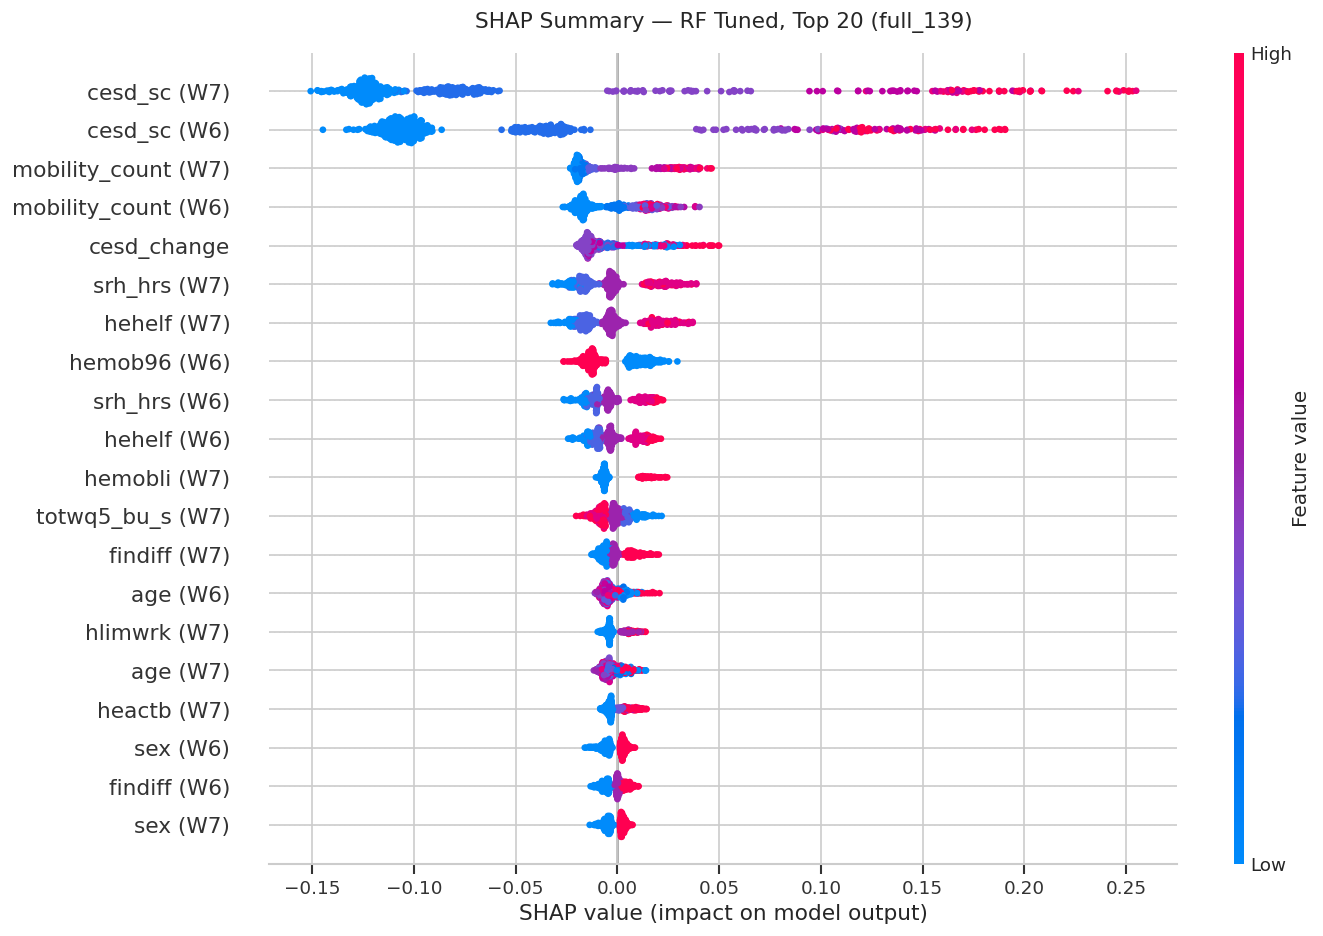

Saved: shap_full_139.png


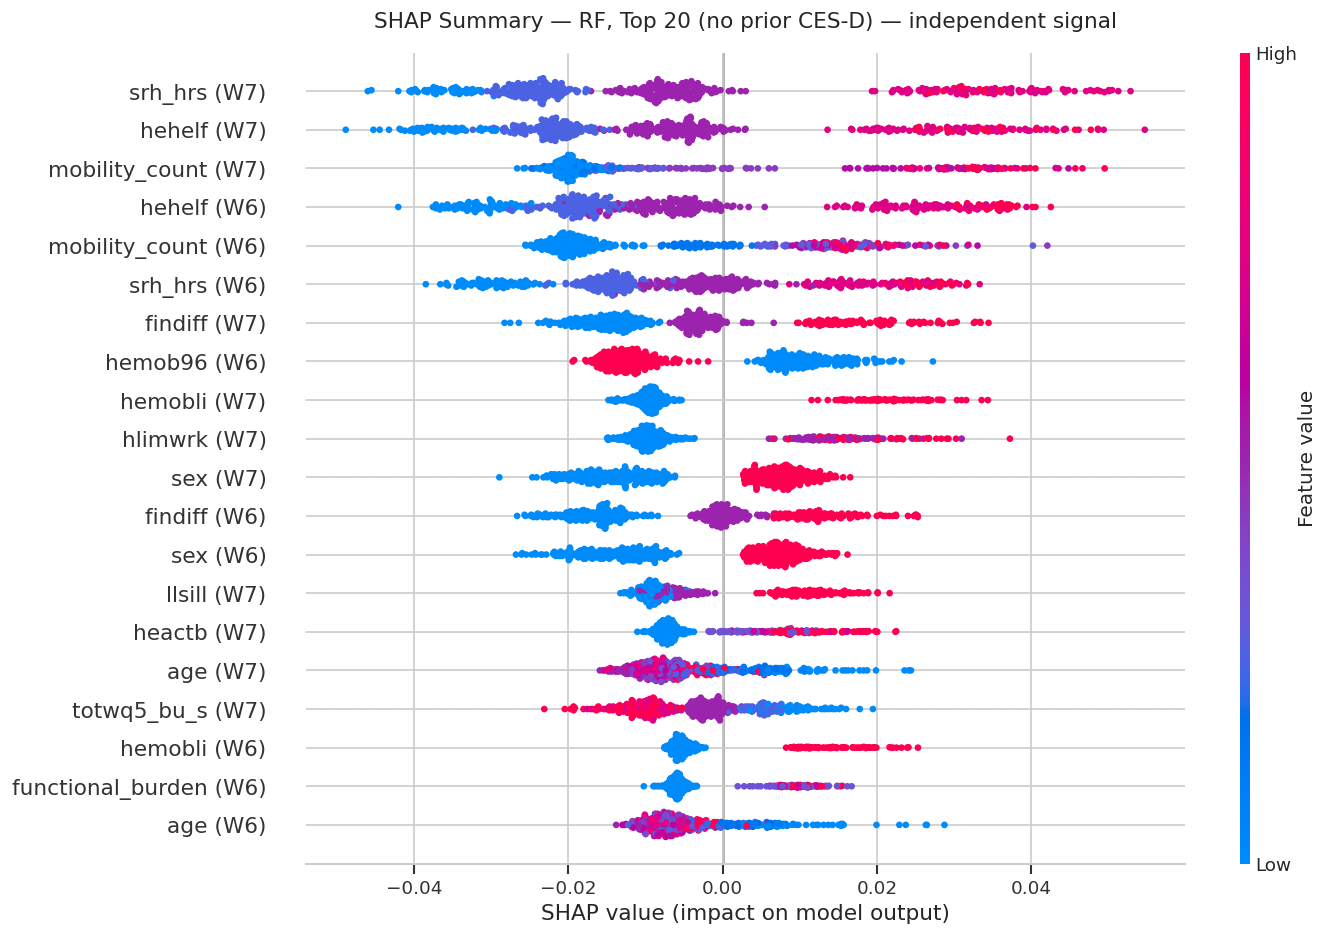

Saved: shap_no_cesd.png


In [23]:
def run_shap(pipe, feat_cols, title, fname, n_sample=500):
    """Run SHAP beeswarm on a fitted RF pipeline and save figure."""
    imputer = pipe.named_steps["imputer"]
    clf     = pipe.named_steps["clf"]

    X_te_sub = X_test_full[feat_cols]
    X_imp    = pd.DataFrame(imputer.transform(X_te_sub),
                            columns=feat_cols, index=X_te_sub.index)
    sample   = X_imp.sample(n=min(n_sample, len(X_imp)), random_state=SEED)

    explainer   = shap.TreeExplainer(clf)
    explanation = explainer(sample)
    sv = explanation.values[:, :, 1] if explanation.values.ndim == 3          else explanation.values

    clean = [c.replace("_w6"," (W6)").replace("_w7"," (W7)") for c in feat_cols]

    plt.figure(figsize=(12, 8))
    shap.summary_plot(sv, sample, feature_names=clean,
                      max_display=20, show=False, plot_size=None)
    plt.title(title, fontsize=13, pad=15)
    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved: {fname}")
    return sv, sample, clean

# --- Act 1: Full model (with prior CES-D) ---
rf_full = rf_search.best_estimator_
sv_full, samp_full, names_full = run_shap(
    rf_full,
    FEATURE_CONFIGS["full_139"],
    "SHAP Summary — RF Tuned, Top 20 (full_139)",
    "shap_full_139.png",
)

# --- Act 2: No prior CES-D --- reveals independent health/social signal
no_cesd_cols = FEATURE_CONFIGS["no_cesd"]
rf_no_cesd   = fitted_store[("no_cesd", "Random Forest")]
sv_nc, samp_nc, names_nc = run_shap(
    rf_no_cesd,
    no_cesd_cols,
    "SHAP Summary — RF, Top 20 (no prior CES-D) — independent signal",
    "shap_no_cesd.png",
)

---
## 13. Final Summary

In [24]:
print("=" * 65)
print("ELSA Depression Prediction — Enhanced Pipeline Complete")
print("=" * 65)
print(f"  Analytic sample:  {len(panel)} participants (W6 + W7 → W8)")
print(f"  Outcome:          CES-D >= {CESD_CUTOFF} at Wave 8 (prevalence: {prev:.1%})")
print(f"  Predictors:       {len(predictor_cols)} features")
print(f"  Train / Test:     {len(X_train_full)} / {len(X_test_full)}")
print()
print("  Main results (full_139, tuned):")
for _, row in tuned_df.iterrows():
    print(f"    {row['Model']:22s}: AUC={row['AUC-ROC']:.3f}  "
          f"F1_binary={row['F1_binary']:.3f}  F1_macro={row['F1_macro']:.3f}")
print()
print("  Leakage check:")
print(f"    Without prior CES-D: RF AUC ~ {results_df[(results_df['config']=='no_cesd') & (results_df['model']=='Random Forest')]['AUC-ROC'].values[0]:.3f}")
print(f"    With prior CES-D:    RF AUC ~ {results_df[(results_df['config']=='full_139') & (results_df['model']=='Random Forest')]['AUC-ROC'].values[0]:.3f}")
print()
print(f"  Figures:  {FIG_DIR}")
print(f"  Results:  {RES_DIR}")
print("=" * 65)

# Save full predictor list
pd.DataFrame({"feature": predictor_cols}).to_csv(
    RES_DIR / "predictor_list_final.csv", index=False
)
print("Saved: predictor_list_final.csv")

ELSA Depression Prediction — Enhanced Pipeline Complete
  Analytic sample:  7211 participants (W6 + W7 → W8)
  Outcome:          CES-D >= 3 at Wave 8 (prevalence: 19.0%)
  Predictors:       138 features
  Train / Test:     5408 / 1803

  Main results (full_139, tuned):
    RF (tuned)            : AUC=0.848  F1_binary=0.582  F1_macro=0.727
    XGB (tuned)           : AUC=0.843  F1_binary=0.580  F1_macro=0.731
    LR (baseline)         : AUC=0.835  F1_binary=0.559  F1_macro=0.711

  Leakage check:
    Without prior CES-D: RF AUC ~ 0.774
    With prior CES-D:    RF AUC ~ 0.840

  Figures:  /content/outputs/figures
  Results:  /content/outputs/results
Saved: predictor_list_final.csv
